# Projeto 1 - Machine Learning: Aprendizagem Supervisionada

**Autor:** Bernardo Nabais
**Dataset:** Airbnb Hong Kong (Inside Airbnb, junho-julho de 2026)

Este notebook documenta a análise exploratória que justifica as decisões
implementadas em `data_preparation.py`, e apresenta as experiências com os
modelos de regressão (`linear_regression.py`) e classificação
(`logistic_regression.py`).

---

## Parte 1 - Análise exploratória

In [2]:

import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("data/listings.csv", low_memory=False)
print("Dimensões originais:", df.shape)
print("Datas de scraping:", df["last_scraped"].unique())

Dimensões originais: (6734, 90)
Datas de scraping: ['2026-06-28' '2026-07-03' '2026-06-29']


### 1.1 Missing values

Primeiro passo: perceber onde faltam dados e distinguir valores
desconhecidos de ausência com significado.

In [3]:
missing = (df.isna().mean() * 100).sort_values(ascending=False)
missing = missing[missing > 0]

print(f"Colunas 100% vazias: {(missing == 100).sum()}")
print(missing[missing == 100].index.tolist())
print("\nColunas com missing parcial:")
print(missing[missing < 100].round(1).to_string())

Colunas 100% vazias: 14
['neighborhood_overview', 'host_since', 'host_response_time', 'host_thumbnail_url', 'host_acceptance_rate', 'host_response_rate', 'host_verifications', 'neighbourhood', 'host_total_listings_count', 'host_neighbourhood', 'calendar_updated', 'instant_bookable', 'license', 'neighbourhood_group_cleansed']

Colunas com missing parcial:
review_scores_location         44.2
review_scores_accuracy         44.2
review_scores_value            44.2
review_scores_communication    44.2
review_scores_cleanliness      44.2
review_scores_rating           44.2
first_review                   44.2
last_review                    44.2
reviews_per_month              44.2
review_scores_checkin          44.2
bedrooms                       43.4
host_about                     37.5
host_location                  33.3
bathrooms                      18.8
beds                           13.3
price                          10.2
price_quote_price_per_night    10.2
price_quote_total_price        

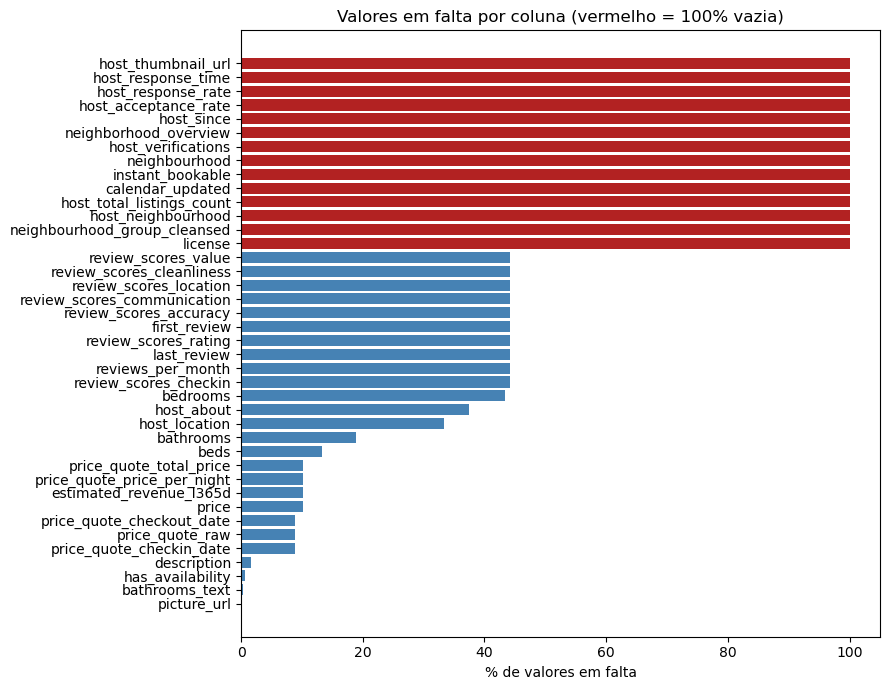

In [4]:
# Figura: percentagem de missing por coluna
fig, ax = plt.subplots(figsize=(9, 7))
m_plot = missing.sort_values()
cores = ["firebrick" if v == 100 else "steelblue" for v in m_plot.values]
ax.barh(m_plot.index, m_plot.values, color=cores)
ax.set_xlabel("% de valores em falta")
ax.set_title("Valores em falta por coluna (vermelho = 100% vazia)")
plt.tight_layout()
plt.savefig("figures/missingness.png", dpi=150, bbox_inches="tight")
plt.show()

In [5]:
# Os missing das reviews acontecem todos nas mesmas linhas?
cols = missing[(missing > 5) & (missing < 100)].index.tolist()
corr = df[cols].isna().astype(int).corr()

print("Correlação entre padrões de missing:")
print(f"  review_scores_rating vs reviews_per_month: "
      f"{corr.loc['review_scores_rating', 'reviews_per_month']:.2f}")
print(f"  review_scores_rating vs first_review:      "
      f"{corr.loc['review_scores_rating', 'first_review']:.2f}")
print(f"  bedrooms vs review_scores_rating:          "
      f"{corr.loc['bedrooms', 'review_scores_rating']:.2f}")
print(f"  bathrooms vs review_scores_rating:         "
      f"{corr.loc['bathrooms', 'review_scores_rating']:.2f}")

Correlação entre padrões de missing:
  review_scores_rating vs reviews_per_month: 1.00
  review_scores_rating vs first_review:      1.00
  bedrooms vs review_scores_rating:          0.28
  bathrooms vs review_scores_rating:         -0.05


**Conclusões:**

- 14 colunas estão 100% vazias nesta versão do ficheiro, incluindo
  `host_response_rate` e `host_response_time`, que o enunciado previa usar.
  São removidas por não terem informação.
- As colunas de reviews têm correlação 1.00 entre si: falham exatamente nas
  mesmas linhas. É **ausência com significado** (alojamentos sem reviews),
  tratada com um indicador `tem_reviews` e imputação por valor neutro.
- `bedrooms` tem correlação 0.28 com as reviews e `bathrooms` praticamente -0.05:
  falham por razões independentes. São **valores desconhecidos**, tratados por
  imputação (duas políticas comparadas mais à frente).
- `bathrooms_text` tem apenas 0.3% de missing, pelo que é usada para recuperar
  valores de `bathrooms` antes de qualquer imputação.

### 1.2 O alvo: preço por noite

A coluna `price` vem em texto (`"$1,181.02"`) e precisa de conversão.
Confirma-se que corresponde ao preço por noite, igual a
`price_quote_price_per_night`. As colunas derivadas do preço
(`price_quote_total_price`, `price_quote_price_per_night`,
`estimated_revenue_l365d`) são excluídas das features para evitar
*data leakage*.

In [6]:
df["price"] = df["price"].str.replace(r"[$,]", "", regex=True).astype(float)

print(f"Linhas sem preço removidas: {df['price'].isna().sum()} "
      f"({df['price'].isna().mean()*100:.1f}%)")
df = df.dropna(subset=["price"]).copy()
print(f"Linhas restantes: {len(df)}\n")

print(df["price"].describe().round(2).to_string())
print("\nQuantis:")
print(df["price"].quantile([0.01, 0.05, 0.25, 0.5, 0.75, 0.95, 0.99, 0.999])
        .round(1).to_string())

Linhas sem preço removidas: 688 (10.2%)
Linhas restantes: 6046

count      6046.00
mean        790.40
std        2699.57
min           0.09
25%         225.95
50%         424.00
75%         883.08
max      171234.00

Quantis:
0.010       97.9
0.050      169.6
0.250      225.9
0.500      424.0
0.750      883.1
0.950     2188.0
0.990     4618.9
0.999    23142.7


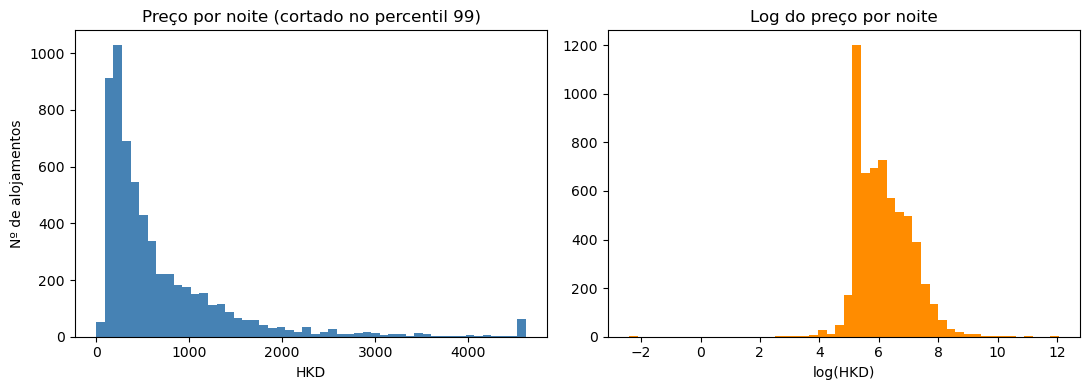

In [7]:
fig, ax = plt.subplots(1, 2, figsize=(11, 4))

limite = df["price"].quantile(0.99)
ax[0].hist(df["price"].clip(upper=limite), bins=50, color="steelblue")
ax[0].set_title("Preço por noite (cortado no percentil 99)")
ax[0].set_xlabel("HKD")
ax[0].set_ylabel("Nº de alojamentos")

ax[1].hist(np.log(df["price"]), bins=50, color="darkorange")
ax[1].set_title("Log do preço por noite")
ax[1].set_xlabel("log(HKD)")

plt.tight_layout()
plt.savefig("figures/preco_vs_log_preco.png", dpi=150, bbox_inches="tight")
plt.show()

A distribuição do preço é fortemente assimétrica à direita (mediana 424 HKD,
máximo 171 234 HKD). O logaritmo aproxima-a de uma normal, o que justifica
usar **log-preço** como alvo dos modelos lineares. Esta escolha é comparada
quantitativamente na Parte 2.

### 1.3 Duração da estadia simulada

O `price` corresponde ao preço de uma estadia simulada com datas específicas.
Como os anfitriões aplicam descontos para estadias longas, a duração pode
afetar o preço por noite.

In [8]:
df["noites"] = (pd.to_datetime(df["price_quote_checkout_date"])
                - pd.to_datetime(df["price_quote_checkin_date"])).dt.days
df["grupo_noites"] = pd.cut(df["noites"], bins=[0, 1, 7, 27, 31, 1000],
                            labels=["1", "2-7", "8-27", "28-31", "32+"])

print(df.groupby("grupo_noites", observed=True)["price"]
        .agg(["count", "median", "mean"]).round(1))

              count  median    mean
grupo_noites                       
1              1882   545.0   982.6
2-7            1266   901.5  1267.3
8-27            227   673.9  1174.7
28-31          2535   221.3   407.1
32+             136   120.7   194.6


**Conclusão:** a duração afeta o preço de forma muito significativa. A mediana
cai de 545 HKD (1 noite) para 221 HKD (28-31 noites). Em Hong Kong, alugar por
menos de 28 noites exige licença, o que explica a concentração de anúncios no
grupo 28-31 (2 535 alojamentos, o maior de todos).

**Decisão:** manter todas as durações e introduzir `noites` (numérica) e
`long_stay` (binária, `noites >= 28`) como features, para o modelo separar o
efeito do desconto do valor do alojamento em si. Filtrar por uma única duração
reduziria a amostra e eliminaria informação sobre dois mercados distintos.

### 1.4 Variáveis do alojamento

In [9]:
print("=== Preço por room_type ===")
print(df.groupby("room_type")["price"].agg(["count", "median", "mean"]).round(1))

print("\n=== Preço mediano por accommodates ===")
print(df.groupby("accommodates")["price"].agg(["count", "median"]).round(1))

print("\n=== Top 10 bairros ===")
print(df.groupby("neighbourhood_cleansed")["price"]
        .agg(["count", "median"]).round(1)
        .sort_values("count", ascending=False).head(10))

=== Preço por room_type ===
                 count  median    mean
room_type                             
Entire home/apt   2209   987.0  1398.2
Hotel room          15   366.0   675.1
Private room      3706   292.1   444.3
Shared room        116   225.0   287.8

=== Preço mediano por accommodates ===
              count  median
accommodates               
1              1628   223.3
2              2746   393.8
3               454   664.0
4               477   906.9
5               155  1256.0
6               245  1327.4
7                82  1348.3
8               124  1386.0
9                24  1629.4
10               48  1641.2
11               14  2187.0
12               12  1321.7
13                2  1911.8
14                5  3021.7
15                5  2569.7
16               25  2454.0

=== Top 10 bairros ===
                        count  median
neighbourhood_cleansed               
Yau Tsim Mong            2430   413.0
Wan Chai                 1283   357.7
Central & Western 

**Observações:**

- `room_type` é a variável mais discriminativa: um Entire home/apt custa em
  mediana 3,4× mais que um Private room (987 vs 292 HKD). Hotel room (15) e
  Shared room (116) têm muito poucas observações.
- O preço cresce com `accommodates` de forma **não linear**: quase duplica de 1
  para 2 pessoas e de 2 para 3, mas abranda a partir das 5. Isto justifica
  testar termos polinomiais.
- Os anúncios concentram-se em 3 bairros (~79% do total), com medianas muito
  diferentes entre si (Islands 931 HKD vs Southern 180 HKD): existe efeito
  espacial.

### 1.5 Efeito espacial

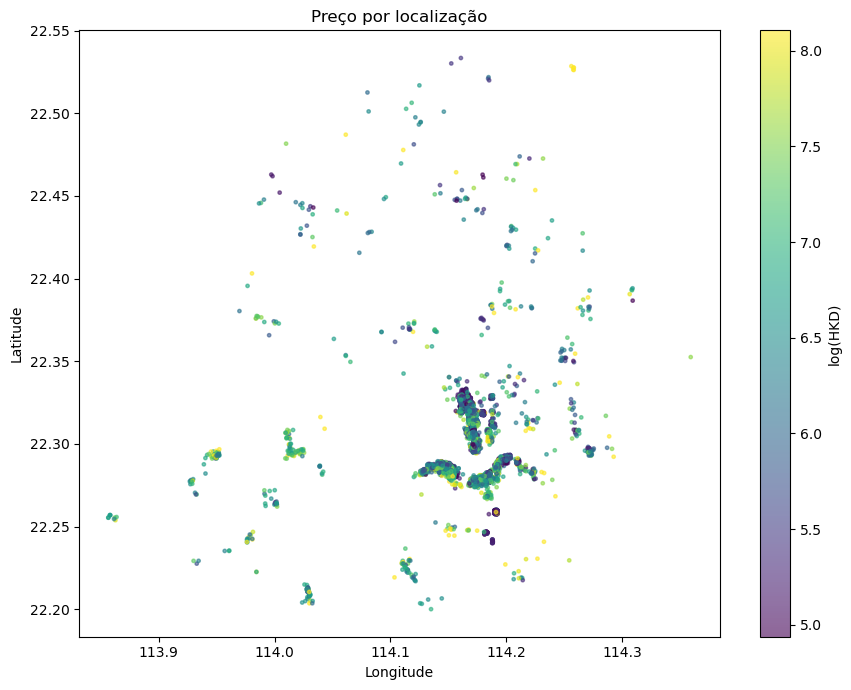

In [10]:
fig, ax = plt.subplots(figsize=(9, 7))
sc = ax.scatter(df["longitude"], df["latitude"], c=np.log(df["price"]),
                s=6, alpha=0.6, cmap="viridis",
                vmin=np.log(df["price"]).quantile(0.02),
                vmax=np.log(df["price"]).quantile(0.98))
plt.colorbar(sc, label="log(HKD)")
ax.set_title("Preço por localização")
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
plt.tight_layout()
plt.savefig("figures/mapa_precos.png", dpi=150, bbox_inches="tight")
plt.show()

O efeito espacial é captado no modelo através de `neighbourhood_cleansed`
(one-hot). As coordenadas brutas não são usadas como features: num modelo
linear, latitude e longitude entrariam como efeitos aditivos, o que não
representa bem a estrutura de bairros de uma cidade.

### 1.6 Outliers

O enunciado pede pelo menos dois critérios robustos. São aplicados o **IQR de
Tukey** e o **MAD** (desvio absoluto mediano), ambos sobre o log-preço por ser
aproximadamente normal. Os dois critérios são robustos porque assentam na
mediana e nos quartis, que não são afetados pelos próprios outliers.

In [38]:
def detetar_outliers(serie, usar_log=True):
    """Deteta outliers por IQR e por MAD. Devolve as duas máscaras e os limites."""
    x = np.log(serie) if usar_log else serie.astype(float)

    # Critério 1: IQR de Tukey
    q1, q3 = x.quantile([0.25, 0.75])
    iqr = q3 - q1
    inf_iqr, sup_iqr = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    out_iqr = (x < inf_iqr) | (x > sup_iqr)

    # Critério 2: MAD (z robusto > 3)
    med = x.median()
    mad = (x - med).abs().median()
    z = (x - med).abs() / (1.4826 * mad) if mad > 0 else (x - med).abs() * 0
    out_mad = z > 3
    inf_mad, sup_mad = med - 3 * 1.4826 * mad, med + 3 * 1.4826 * mad

    if usar_log:
        inf_iqr, sup_iqr = np.exp(inf_iqr), np.exp(sup_iqr)
        inf_mad, sup_mad = np.exp(inf_mad), np.exp(sup_mad)

    return out_iqr, out_mad, (inf_iqr, sup_iqr), (inf_mad, sup_mad)


def resumo_outliers(nome, serie, usar_log=True):
    out_iqr, out_mad, lim_iqr, lim_mad = detetar_outliers(serie, usar_log)
    print(f"=== {nome} ===")
    print(f"  IQR:    {out_iqr.sum():4d} ({out_iqr.mean()*100:.2f}%)  "
          f"limites [{lim_iqr[0]:.1f}, {lim_iqr[1]:.1f}]")
    print(f"  MAD:    {out_mad.sum():4d} ({out_mad.mean()*100:.2f}%)  "
          f"limites [{lim_mad[0]:.1f}, {lim_mad[1]:.1f}]")
    print(f"  União:  {(out_iqr | out_mad).sum():4d}")
    print(f"  Ambos:  {(out_iqr & out_mad).sum():4d}\n")
    return out_iqr, out_mad


out_iqr, out_mad = resumo_outliers("price (log)", df["price"])
resumo_outliers("minimum_nights", df["minimum_nights"], usar_log=False)
resumo_outliers("accommodates", df["accommodates"], usar_log=False);

=== price (log) ===
  IQR:      40 (0.66%)  limites [29.2, 6823.3]
  MAD:      28 (0.46%)  limites [21.2, 8485.2]
  União:    40
  Ambos:    28

=== minimum_nights ===
  IQR:      82 (1.36%)  limites [-41.0, 71.0]
  MAD:    2604 (43.07%)  limites [-12.8, 22.8]
  União:  2604
  Ambos:    82

=== accommodates ===
  IQR:     341 (5.64%)  limites [-2.0, 6.0]
  MAD:     341 (5.64%)  limites [-2.4, 6.4]
  União:   341
  Ambos:   341



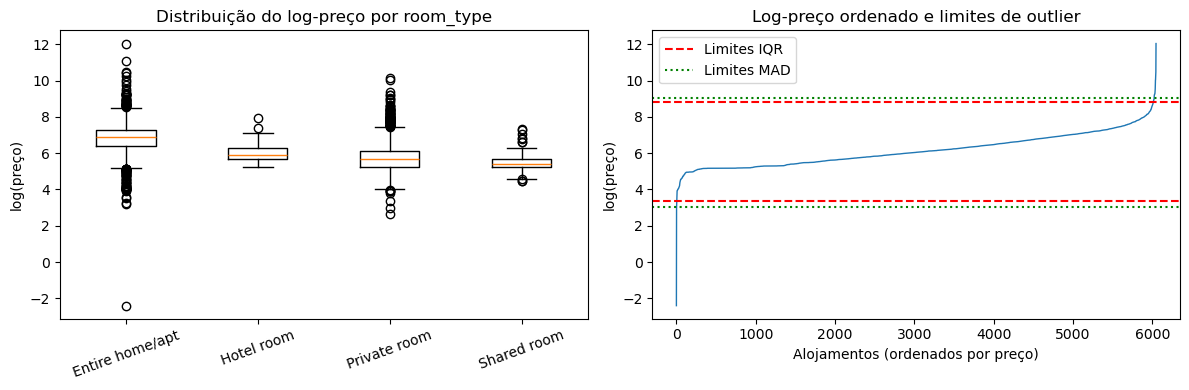

In [15]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4))

# (a) Boxplot do log-preço por room_type
dados = [np.log(df.loc[df["room_type"] == rt, "price"])
         for rt in sorted(df["room_type"].unique())]
ax[0].boxplot(dados, tick_labels=sorted(df["room_type"].unique()))
ax[0].set_ylabel("log(preço)")
ax[0].set_title("Distribuição do log-preço por room_type")
ax[0].tick_params(axis="x", rotation=20)

# (b) Log-preço ordenado, com os limites dos dois critérios
_, _, lim_iqr, lim_mad = detetar_outliers(df["price"])
ax[1].plot(sorted(np.log(df["price"])), linewidth=1)
ax[1].axhline(np.log(lim_iqr[0]), color="red", ls="--", label="Limites IQR")
ax[1].axhline(np.log(lim_iqr[1]), color="red", ls="--")
ax[1].axhline(np.log(lim_mad[0]), color="green", ls=":", label="Limites MAD")
ax[1].axhline(np.log(lim_mad[1]), color="green", ls=":")
ax[1].set_xlabel("Alojamentos (ordenados por preço)")
ax[1].set_ylabel("log(preço)")
ax[1].set_title("Log-preço ordenado e limites de outlier")
ax[1].legend()

plt.tight_layout()
plt.savefig("figures/outliers.png", dpi=150, bbox_inches="tight")
plt.show()

In [13]:
cols = ["price", "room_type", "accommodates", "neighbourhood_cleansed", "noites"]
print("=== 5 preços mais baixos ===")
print(df.nsmallest(5, "price")[cols].to_string())
print("\n=== 5 preços mais altos ===")
print(df.nlargest(5, "price")[cols].to_string())

=== 5 preços mais baixos ===
      price        room_type  accommodates neighbourhood_cleansed  noites
2429   0.09  Entire home/apt             4               Sai Kung     300
3125  14.51     Private room             1                Eastern     291
3238  20.00     Private room             2           Sham Shui Po     259
1996  25.05  Entire home/apt             2                 Tai Po     365
1995  25.86  Entire home/apt             2                 Tai Po     365

=== 5 preços mais altos ===
          price        room_type  accommodates neighbourhood_cleansed  noites
1605  171234.00  Entire home/apt             3      Central & Western       2
3980   67202.00  Entire home/apt            16              Kwun Tong       1
4451   35765.00  Entire home/apt             6               Sai Kung       1
2694   34246.00  Entire home/apt            16               Southern       1
3983   29214.13  Entire home/apt            12               Tuen Mun       1


**Conclusões sobre outliers:**

**Preço.** Os dois critérios concordam na ordem de grandeza: IQR assinala 40
alojamentos (0,66%) e MAD 28 (0,46%), estando os 28 do MAD contidos nos 40 do
IQR. Os preços muito baixos associam-se a estadias muito longas (259-365
noites) e parecem erros de listagem ou valores parciais (o mínimo é 0,09 HKD);
os muito altos associam-se a estadias curtas em Entire home/apt, com um máximo
de 171 234 HKD claramente implausível. Três estratégias são comparadas na
Parte 2: sem tratamento, capping (winsorização nos limites do IQR) e filtragem
robusta (remoção da união IQR ∪ MAD).

**`minimum_nights`.** Os dois critérios divergem radicalmente: o IQR assinala
82 alojamentos (1,4%) e o MAD 2 604 (43,1%). A explicação está na distribuição
bimodal desta variável (concentrada em 1 noite e em 28-31 noites, por efeito da
regulação de Hong Kong). O MAD pressupõe uma distribuição unimodal; perante
dois modos distantes, o desvio absoluto mediano torna-se pequeno e todo o
segundo grupo é classificado como anómalo. Um critério que marca 43% das
observações não está a detetar erros, está a sinalizar que a sua premissa não
se verifica. A variável **não é tratada**: os valores refletem comportamento
real do mercado e são informativos para o modelo.

**`accommodates`.** Ambos os critérios assinalam exatamente os mesmos 341
alojamentos (5,64%), correspondentes a capacidade superior a 6 pessoas. Não são
erros de registo, mas alojamentos de grupo com preços coerentes com a dimensão.
A variável **não é tratada**, sendo em vez disso modelada com um termo
polinomial para captar a relação não linear com o preço.

**Nota.** Os limites inferiores calculados por ambos os critérios são negativos
para estas duas variáveis (−41 noites, −2 pessoas), o que é impossível e
confirma que os critérios foram concebidos para distribuições aproximadamente
simétricas. Apenas o limite superior tem significado nestes casos.

**Nota metodológica.** O tratamento de outliers é aplicado **apenas ao conjunto
de treino**. Alterar o alvo na validação e no teste produziria métricas
otimistas e não comparáveis entre estratégias, uma vez que o erro passaria a
ser medido contra valores artificialmente limitados.

### 1.7 Amenities

In [14]:
df["amenities_lista"] = df["amenities"].apply(json.loads)
df["n_amenities"] = df["amenities_lista"].apply(len)

todas = [a for lista in df["amenities_lista"] for a in lista]
print(f"Amenities distintas: {len(set(todas))}")
print(f"Nº de amenities por alojamento: mediana {df['n_amenities'].median():.0f}, "
      f"min {df['n_amenities'].min()}, max {df['n_amenities'].max()}\n")

top15 = pd.Series(todas).value_counts().head(15)
print("Top 15 amenities (usadas como features binárias):")
for nome, n in top15.items():
    print(f"  {n:5d}  ({n/len(df)*100:5.1f}%)  {nome}")

Amenities distintas: 871
Nº de amenities por alojamento: mediana 14, min 0, max 76

Top 15 amenities (usadas como features binárias):
   5688  ( 94.1%)  Wifi
   5397  ( 89.3%)  Air conditioning
   4071  ( 67.3%)  Kitchen
   3427  ( 56.7%)  Hot water
   3367  ( 55.7%)  Hangers
   3095  ( 51.2%)  Washer
   3063  ( 50.7%)  Hair dryer
   3045  ( 50.4%)  TV
   2679  ( 44.3%)  Shampoo
   2611  ( 43.2%)  Elevator
   2593  ( 42.9%)  Iron
   2501  ( 41.4%)  Essentials
   2377  ( 39.3%)  Bed linens
   2259  ( 37.4%)  Smoke alarm
   2198  ( 36.4%)  Refrigerator


Com 871 amenities distintas, criar uma coluna por cada seria impraticável e a
maioria apareceria em pouquíssimos alojamentos. A abordagem adotada é:

- `n_amenities`: número total de comodidades, como feature-resumo.
- Uma **binária por cada uma das 15 amenities mais frequentes**.

As 15 mais comuns são selecionadas sobre o dataset completo, antes do split.
Como a seleção não usa o preço, o risco de leakage é desprezável.

---

## Parte 2 - Regressão

### 2.1 Metodologia

Todos os modelos são implementados de raiz em `linear_regression.py` com
**batch gradient descent**, sem recurso a bibliotecas de machine learning.

A avaliação usa **k-fold cross-validation com 5 folds**. Dentro de cada fold,
todo o pré-processamento que aprende parâmetros a partir dos dados (medianas
de imputação, limites de outliers, média e desvio para standardização) é
calculado **apenas no subconjunto de treino desse fold** e só depois aplicado
à partição de validação. É isto que garante ausência de *data leakage*: se o
pré-processamento fosse feito antes da divisão em folds, as estatísticas já
teriam visto os dados de validação.

In [16]:
from data_preparation import (carregar_dados, criar_features_duracao,
                               extrair_bathrooms, criar_features_amenities,
                               kfold_indices, preparar_fold)
from linear_regression import treinar, prever, metricas, plot_convergencia

# Dataframe base, sem imputação nem escala (isso acontece dentro de cada fold)
base = carregar_dados()
base = criar_features_duracao(base)
base = extrair_bathrooms(base)
base = criar_features_amenities(base)
folds = kfold_indices(len(base), k=5, seed=42)

print(f"Dataset: {len(base)} alojamentos, {len(folds)} folds")


def correr_kfold(usar_log=True, polinomiais=False, interacoes=False,
                 est_missing="simples", est_outliers="nenhuma",
                 l2=0.0, taxa=0.01, n_iters=2000):
    """Corre k-fold com as opções dadas e devolve média e desvio das métricas."""
    resultados = []
    for tr_idx, val_idx in folds:
        X_tr, (X_val,), y_tr, (y_val,) = preparar_fold(
            base, tr_idx, val_idx,
            estrategia_missing=est_missing, estrategia_outliers=est_outliers,
            polinomiais=polinomiais, interacoes=interacoes,
        )
        if not usar_log:                      # voltar ao preço em HKD
            y_tr, y_val = np.exp(y_tr), np.exp(y_val)
        pesos, bias, _ = treinar(X_tr, y_tr, taxa=taxa, n_iters=n_iters, l2=l2)
        resultados.append(metricas(y_val, prever(X_val, pesos, bias)))

    return {k: (np.mean([r[k] for r in resultados]),
                np.std([r[k] for r in resultados]))
            for k in ["MAE", "RMSE", "R2"]}

Dataset: 6046 alojamentos, 5 folds


### 2.2 Alvo, termos polinomiais e interações

Comparação entre prever o preço em HKD, o log-preço, e o log-preço com
features adicionais. As métricas do preço bruto estão em HKD e as do
log-preço em unidades logarítmicas, pelo que **MAE e RMSE não são comparáveis
entre as duas primeiras linhas**. O R², por ser adimensional, permite a
comparação.

In [17]:
configs = [
    ("Preço bruto (HKD)",              dict(usar_log=False)),
    ("Log-preço",                      dict(usar_log=True)),
    ("Log + polinomiais",              dict(usar_log=True, polinomiais=True)),
    ("Log + polinomiais + interações", dict(usar_log=True, polinomiais=True,
                                            interacoes=True)),
]

print(f"{'Modelo':34} {'MAE':>18} {'RMSE':>18} {'R2':>16}")
print("-" * 88)
for nome, kw in configs:
    m = correr_kfold(**kw)
    print(f"{nome:34} {m['MAE'][0]:10.3f} ±{m['MAE'][1]:6.3f} "
          f"{m['RMSE'][0]:10.3f} ±{m['RMSE'][1]:6.3f} "
          f"{m['R2'][0]:8.3f} ±{m['R2'][1]:6.3f}")

Modelo                                            MAE               RMSE               R2
----------------------------------------------------------------------------------------
Preço bruto (HKD)                     503.494 ±45.264   2018.903 ±1627.685    0.188 ± 0.083
Log-preço                               0.364 ± 0.008      0.519 ± 0.021    0.660 ± 0.015
Log + polinomiais                       0.359 ± 0.008      0.514 ± 0.020    0.667 ± 0.014
Log + polinomiais + interações          0.355 ± 0.008      0.510 ± 0.020    0.672 ± 0.014


**Conclusões:**

- O **log-preço** é a transformação decisiva: eleva o R² de 0.188 para 0.660.
  Além disso, estabiliza o modelo — o RMSE em HKD varia ±1 628 entre folds
  (quase tanto como o próprio valor médio), enquanto em log varia apenas ±0.02
  sobre 0.51. Um único alojamento extremo num fold basta para desestabilizar o
  modelo treinado em escala original.
- Os **termos polinomiais** (`accommodates²`, `n_amenities²`) acrescentam
  +0.007 ao R², consistente com a curvatura observada na análise exploratória.
- As **interações** `long_stay × room_type` acrescentam mais +0.005,
  sugerindo que o desconto por estadia longa não é uniforme entre tipos de
  alojamento.

**Nota de implementação:** os termos polinomiais têm de ser construídos
**antes** da standardização. Numa versão anterior foram calculados sobre
features já centradas em zero, o que destrói a informação de direção (valores
simétricos ficam iguais ao quadrado) e fazia o modelo piorar.

### 2.3 Regularização L2

In [18]:
print("Comparação de valores de regularização L2 (modelo completo)\n")
print(f"{'L2':>8} {'MAE':>18} {'RMSE':>18} {'R2':>16}")
print("-" * 64)
for l2 in [0.0, 0.001, 0.01, 0.1, 1.0]:
    m = correr_kfold(polinomiais=True, interacoes=True, l2=l2)
    print(f"{l2:8.3f} {m['MAE'][0]:10.3f} ±{m['MAE'][1]:6.3f} "
          f"{m['RMSE'][0]:10.3f} ±{m['RMSE'][1]:6.3f} "
          f"{m['R2'][0]:8.3f} ±{m['R2'][1]:6.3f}")

Comparação de valores de regularização L2 (modelo completo)

      L2                MAE               RMSE               R2
----------------------------------------------------------------
   0.000      0.355 ± 0.008      0.510 ± 0.020    0.672 ± 0.014
   0.001      0.354 ± 0.008      0.509 ± 0.020    0.673 ± 0.014
   0.010      0.351 ± 0.008      0.506 ± 0.020    0.677 ± 0.014
   0.100      0.357 ± 0.009      0.511 ± 0.021    0.671 ± 0.014
   1.000      0.419 ± 0.011      0.574 ± 0.023    0.585 ± 0.019


### 2.4 Estratégias de pré-processamento

Comparação das duas políticas de imputação com as três estratégias de
tratamento de outliers, todas avaliadas com k-fold e com o modelo completo
(log-preço, polinomiais e interações).

In [19]:
linhas = []
for est_m in ["simples", "agrupada"]:
    for est_o in ["nenhuma", "capping", "filtragem"]:
        m = correr_kfold(polinomiais=True, interacoes=True,
                         est_missing=est_m, est_outliers=est_o)
        linhas.append({"Imputação": est_m, "Outliers": est_o,
                       "MAE": round(m["MAE"][0], 4),
                       "RMSE": round(m["RMSE"][0], 4),
                       "R2": round(m["R2"][0], 4)})
        print(f"{est_m:9} + {est_o:10} →  MAE={m['MAE'][0]:.4f}  "
              f"RMSE={m['RMSE'][0]:.4f}  R2={m['R2'][0]:.4f}")

tabela = pd.DataFrame(linhas)
tabela.to_csv("report/ablacoes.csv", index=False)
print("\nTabela guardada em report/ablacoes.csv")

simples   + nenhuma    →  MAE=0.3548  RMSE=0.5100  R2=0.6717
simples   + capping    →  MAE=0.3541  RMSE=0.5104  R2=0.6713
simples   + filtragem  →  MAE=0.3543  RMSE=0.5131  R2=0.6678
agrupada  + nenhuma    →  MAE=0.3550  RMSE=0.5103  R2=0.6713
agrupada  + capping    →  MAE=0.3542  RMSE=0.5107  R2=0.6709
agrupada  + filtragem  →  MAE=0.3545  RMSE=0.5133  R2=0.6675

Tabela guardada em report/ablacoes.csv


**Conclusões sobre regularização:**

A regularização L2 apresenta a curva em U esperada: o desempenho melhora até
λ = 0.01 (R² 0.677) e degrada-se para valores maiores, colapsando em λ = 1.0
(R² 0.585), onde a penalização domina a função de custo e empurra os pesos
para zero. **λ = 0.01 é o valor escolhido**, selecionado por k-fold sobre o
conjunto de treino, nunca com recurso ao conjunto de teste.

**Conclusões sobre as estratégias de pré-processamento:**

- **Outliers:** nenhuma das três estratégias produz diferença relevante. As
  métricas discordam entre si (o capping tem o melhor MAE, a ausência de
  tratamento o melhor RMSE e R²) e todas as diferenças estão na terceira casa
  decimal, muito abaixo do desvio entre folds (±0.020 no RMSE). A explicação
  provável é que o alvo já está em escala logarítmica, que por si só comprime
  os valores extremos; winsorizar algo já logaritmizado acrescenta pouco. A
  **filtragem é consistentemente a pior** das três, o que sugere que remover 40
  observações do treino retira mais informação do que o ruído que elimina.
- **Imputação:** as duas políticas produzem resultados praticamente idênticos
  (diferenças na quarta casa decimal). Explicação provável: `bedrooms`,
  `bathrooms` e `beds` estão fortemente correlacionadas com `accommodates`, que
  não tem valores em falta, pelo que o modelo já dispõe dessa informação por
  outra via.

**Configuração final escolhida:** log-preço, com termos polinomiais e
interações, imputação simples, sem tratamento de outliers, e L2 = 0.01. É a
combinação com melhor R² e, simultaneamente, a mais simples — nenhuma das
alternativas mais elaboradas justificou a sua complexidade adicional.

### 2.5 Modelo final

Features: 51
Treino: 4232  Validação: 906  Teste: 908

Treino     MAE=0.3441  RMSE=0.5014  R2=0.6808
Validação  MAE=0.3560  RMSE=0.5107  R2=0.6908
Teste      MAE=0.3609  RMSE=0.4989  R2=0.6746


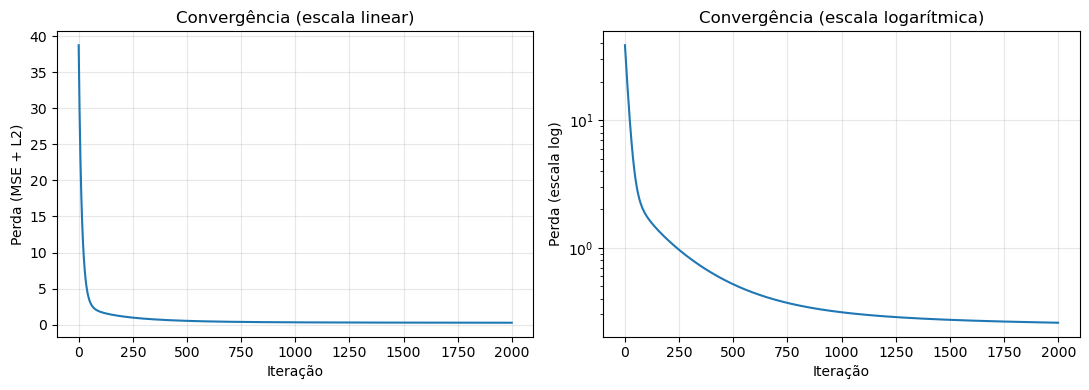

In [22]:
from data_preparation import (split_treino_val_teste, tratar_missing,
                               tratar_outliers, listar_features,
                               preparar_matriz_final)

# Configuração final
L2_FINAL = 0.01

treino, val, teste = split_treino_val_teste(base, seed=42)
treino, (val, teste) = tratar_missing(treino, [val, teste], "simples")
treino, (val, teste) = tratar_outliers(treino, [val, teste], "nenhuma")

f_num, f_cat = listar_features(treino)
X_treino, (X_val, X_teste), y_treino, (y_val, y_teste) = preparar_matriz_final(
    treino, [val, teste], f_num, f_cat, polinomiais=True, interacoes=True
)

pesos, bias, hist = treinar(X_treino, y_treino, taxa=0.01,
                            n_iters=2000, l2=L2_FINAL)

print(f"Features: {X_treino.shape[1]}")
print(f"Treino: {len(X_treino)}  Validação: {len(X_val)}  Teste: {len(X_teste)}\n")
for nome, X, y in [("Treino", X_treino, y_treino),
                   ("Validação", X_val, y_val),
                   ("Teste", X_teste, y_teste)]:
    m = metricas(y, prever(X, pesos, bias))
    print(f"{nome:10} MAE={m['MAE']:.4f}  RMSE={m['RMSE']:.4f}  R2={m['R2']:.4f}")

fig, ax = plt.subplots(1, 2, figsize=(11, 4))

ax[0].plot(hist)
ax[0].set_xlabel("Iteração")
ax[0].set_ylabel("Perda (MSE + L2)")
ax[0].set_title("Convergência (escala linear)")
ax[0].grid(True, alpha=0.3)

ax[1].plot(hist)
ax[1].set_yscale("log")
ax[1].set_xlabel("Iteração")
ax[1].set_ylabel("Perda (escala log)")
ax[1].set_title("Convergência (escala logarítmica)")
ax[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("figures/convergencia_linear.png", dpi=150, bbox_inches="tight")
plt.show()

**Convergência:** em escala linear a perda parece estabilizar por volta das 200
iterações, mas a escala logarítmica revela que continua a diminuir lentamente
até ao fim do treino, sem oscilações. Isto confirma que a taxa de aprendizagem
(0.01) é adequada: uma taxa demasiado alta produziria oscilação visível, uma
demasiado baixa deixaria a curva ainda em queda acentuada no final.

### 2.6 Análise de resíduos

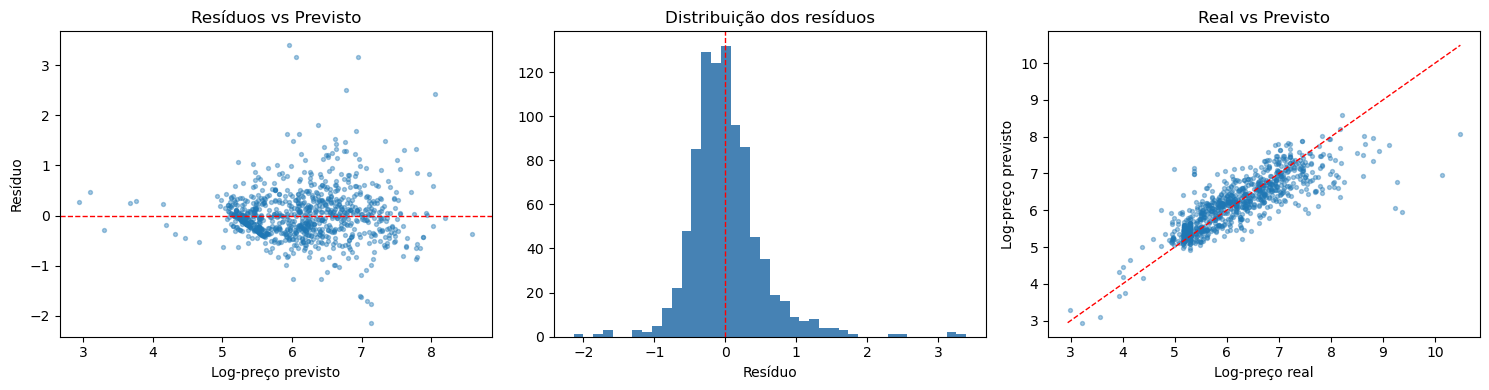

Média dos resíduos: 0.0085
Desvio-padrão:      0.5107


In [24]:
y_pred_val = prever(X_val, pesos, bias)
residuos = y_val.values - y_pred_val

fig, ax = plt.subplots(1, 3, figsize=(15, 4))

ax[0].scatter(y_pred_val, residuos, s=8, alpha=0.4)
ax[0].axhline(0, color="red", ls="--", lw=1)
ax[0].set_xlabel("Log-preço previsto")
ax[0].set_ylabel("Resíduo")
ax[0].set_title("Resíduos vs Previsto")

ax[1].hist(residuos, bins=40, color="steelblue")
ax[1].axvline(0, color="red", ls="--", lw=1)
ax[1].set_xlabel("Resíduo")
ax[1].set_title("Distribuição dos resíduos")

ax[2].scatter(y_val, y_pred_val, s=8, alpha=0.4)
lims = [min(y_val.min(), y_pred_val.min()), max(y_val.max(), y_pred_val.max())]
ax[2].plot(lims, lims, color="red", ls="--", lw=1)
ax[2].set_xlabel("Log-preço real")
ax[2].set_ylabel("Log-preço previsto")
ax[2].set_title("Real vs Previsto")

plt.tight_layout()
plt.savefig("figures/residuos.png", dpi=150, bbox_inches="tight")
plt.show()

print(f"Média dos resíduos: {residuos.mean():.4f}")
print(f"Desvio-padrão:      {residuos.std():.4f}")

In [29]:

analise = val.copy()
analise["residuo"] = residuos
analise["erro_abs"] = np.abs(residuos)
analise["grupo_noites"] = pd.cut(analise["noites"], bins=[0, 1, 7, 27, 31, 1000],
                                  labels=["1", "2-7", "8-27", "28-31", "32+"])
print("=== Erro por room_type ===")
print(analise.groupby("room_type")
             .agg(n=("erro_abs", "size"),
                  erro_medio=("erro_abs", "mean"),
                  vies=("residuo", "mean")).round(3)
             .sort_values("erro_medio", ascending=False))

print("\n=== Erro por bairro (top 10 por nº de alojamentos) ===")
print(analise.groupby("neighbourhood_cleansed")
             .agg(n=("erro_abs", "size"),
                  erro_medio=("erro_abs", "mean"),
                  vies=("residuo", "mean")).round(3)
             .sort_values("n", ascending=False).head(10))

print("\n=== Erro por grupo de duração ===")
print(analise.groupby("grupo_noites", observed=True)
             .agg(n=("erro_abs", "size"),
                  erro_medio=("erro_abs", "mean"),
                  vies=("residuo", "mean")).round(3))

=== Erro por room_type ===
                   n  erro_medio   vies
room_type                              
Shared room       16       0.792 -0.641
Entire home/apt  330       0.402  0.081
Hotel room         3       0.395 -0.012
Private room     557       0.316 -0.015

=== Erro por bairro (top 10 por nº de alojamentos) ===
                          n  erro_medio   vies
neighbourhood_cleansed                        
Yau Tsim Mong           366       0.327 -0.004
Wan Chai                190       0.342 -0.085
Central & Western       152       0.342  0.193
Islands                  40       0.413 -0.103
Eastern                  36       0.353 -0.085
Kowloon City             35       0.305 -0.114
Sham Shui Po             20       0.307 -0.038
Sai Kung                 18       0.746 -0.093
Southern                 16       0.250 -0.070
Sha Tin                   6       0.707  0.299

=== Erro por grupo de duração ===
                n  erro_medio   vies
grupo_noites                        
1   

In [30]:
coefs = pd.DataFrame({"feature": X_treino.columns, "coeficiente": pesos})
coefs["efeito_pct"] = (np.exp(coefs["coeficiente"]) - 1) * 100
coefs = coefs.reindex(coefs["coeficiente"].abs().sort_values(ascending=False).index)

print(f"Intercept (bias): {bias:.4f}\n")
print("=== Top 20 coeficientes por magnitude ===")
print(coefs.head(20).round(3).to_string(index=False))

coefs.to_csv("report/coeficientes_linear.csv", index=False)
print(f"\nTabela completa ({len(coefs)} features) guardada em "
      f"report/coeficientes_linear.csv")

Intercept (bias): 6.3561

=== Top 20 coeficientes por magnitude ===
                             feature  coeficiente  efeito_pct
                        accommodates        0.399      48.991
               room_type_Shared room       -0.274     -23.940
                         n_amenities        0.273      31.381
              room_type_Private room       -0.257     -22.662
      neighbourhood_cleansed_Islands        0.225      25.205
  long_stay_x_room_type_Private room       -0.217     -19.541
      neighbourhood_cleansed_Eastern        0.200      22.123
                              noites       -0.169     -15.561
     neighbourhood_cleansed_Southern        0.166      18.015
                     accommodates_sq       -0.146     -13.562
 neighbourhood_cleansed_Kowloon City        0.140      15.058
     neighbourhood_cleansed_Wan Chai        0.131      14.015
                      tem_essentials        0.091       9.556
                           long_stay       -0.090      -8.593
  

**Análise de resíduos:** a média dos resíduos é 0.0085 (praticamente zero) e a
distribuição aproxima-se de uma normal centrada, validando as premissas do
modelo linear. O gráfico de resíduos vs previsto não revela padrão sistemático
de heterocedasticidade.

**Erro por grupo:** o erro é inversamente proporcional ao número de
observações. Private room (557 obs.) tem erro médio 0.316 e viés quase nulo
(−0.015), enquanto Shared room (16 obs.) tem erro 0.792 e viés de −0.641 — o
modelo **sobrestima sistematicamente** os quartos partilhados em cerca de 90%.
Padrão idêntico nos bairros: Yau Tsim Mong (366 obs., erro 0.327) contra Sai
Kung (18 obs., erro 0.746) e Sha Tin (6 obs., erro 0.707). Estas estimativas
para grupos muito pequenos são instáveis: Hotel room, com apenas 3 observações,
apresentava viés de +0.749 numa configuração anterior do modelo e −0.012 nesta.

**Erro por duração da estadia:** o viés é praticamente nulo nos grupos de 1 a
31 noites (entre −0.004 e +0.059), o que confirma que as features `noites` e
`long_stay` captam adequadamente o efeito do desconto por estadia longa. O
grupo 28-31 apresenta inclusivamente o menor erro médio (0.270), coerente com
preços mais homogéneos nesse segmento (derivados de valores mensais). Isto
valida a decisão de manter todas as durações em vez de filtrar o dataset.

### 2.7 Interpretação dos coeficientes

Os coeficientes estão em escala logarítmica; a coluna `efeito_pct` traduz cada
um em variação percentual do preço (`exp(β) − 1`). As features numéricas estão
standardizadas, pelo que o efeito corresponde a **um desvio-padrão** da
variável. As categóricas são relativas à categoria base (Entire home/apt para
`room_type`, Central & Western para o bairro).

| Feature | β | Efeito | Interpretação |
|---|---|---|---|
| `accommodates` | +0.399 | +49.0% | Capacidade é o fator mais forte |
| `accommodates_sq` | −0.146 | −13.6% | Retornos decrescentes (curvatura) |
| `n_amenities` | +0.273 | +31.4% | Mais comodidades, maior preço |
| `room_type_Shared room` | −0.274 | −23.9% | Face a Entire home/apt |
| `room_type_Private room` | −0.257 | −22.7% | Face a Entire home/apt |
| `long_stay_x_Private room` | −0.217 | −19.5% | Desconto de estadia longa maior em quartos privados |
| `neighbourhood_Islands` | +0.225 | +25.2% | Bairro mais caro |
| `noites` | −0.169 | −15.6% | Estadias longas, preço/noite menor |
| `long_stay` | −0.090 | −8.6% | Efeito adicional do limiar das 28 noites |
| `number_of_reviews` | −0.069 | −6.6% | Ver nota abaixo |

**Notas de interpretação:**

- Os sinais são todos coerentes com a análise exploratória. A combinação de
  `accommodates` positivo com `accommodates²` negativo reproduz exatamente a
  curvatura observada na Secção 1.4.
- A interação `long_stay × Private room` é um dos coeficientes mais fortes,
  mostrando que o desconto por estadia longa é substancialmente maior em
  quartos privados do que em alojamentos inteiros.
- `number_of_reviews` tem coeficiente **negativo**. Uma leitura causal
  ("mais reviews baixam o preço") não faz sentido; a explicação plausível é
  inversa: alojamentos mais baratos têm maior taxa de ocupação e acumulam mais
  reviews. Trata-se de correlação, não de causalidade — limitação intrínseca
  da interpretação de coeficientes em modelos observacionais.

**Nota sobre multicolinearidade:** uma versão anterior do modelo incluía
`property_type` (55 categorias) a par de `room_type`. Uma tabela de
contingência mostrou redundância total — cada categoria de `property_type`
corresponde exclusivamente a um `room_type` — e os coeficientes resultantes
tinham sinais contraditórios (Private room aparecia com coeficiente positivo,
contrariando a análise exploratória). `property_type` foi removida, o que
reduziu a matriz de 109 para 51 features e tornou os coeficientes
interpretáveis.

---

## Parte 3 - Classificação

### 3.1 Definição da classe positiva

A classe positiva é definida como os alojamentos cujo preço está acima do
**percentil 80 dentro do seu grupo** `room_type × neighbourhood_cleansed`. A
definição por grupo é mais informativa do que um limiar global: identifica
alojamentos caros **face a alternativas comparáveis**, em vez de simplesmente
replicar a distinção entre tipos de alojamento e bairros, que o modelo de
regressão já captura.

**Duas precauções contra leakage:**

1. Os limiares são estimados **exclusivamente no conjunto de treino** e
   aplicados à validação e ao teste. Calculá-los dentro de cada conjunto faria
   com que o rótulo dependesse da distribuição do próprio conjunto de
   avaliação.
2. Os rótulos são construídos sobre os **preços originais**, antes de qualquer
   tratamento de outliers, para não dependerem de uma escolha de
   pré-processamento.

Consequência esperada: a proporção de positivos é exatamente 20% no treino,
mas pode afastar-se ligeiramente na validação e no teste — comportamento
realista, já que num cenário real os limiares vêm sempre do passado.

In [31]:
from logistic_regression import (definir_classe_positiva,
                                  treinar as treinar_log,
                                  prever_prob, prever_classe,
                                  metricas as metricas_log)

# Rótulos: limiares aprendidos no treino, aplicados aos três conjuntos
y_treino_bin = definir_classe_positiva(treino)
y_val_bin = definir_classe_positiva(val, df_ref=treino)
y_teste_bin = definir_classe_positiva(teste, df_ref=treino)

print("Proporção de alojamentos na classe positiva:")
print(f"  Treino:    {y_treino_bin.mean()*100:.1f}%  ({y_treino_bin.sum()} de {len(y_treino_bin)})")
print(f"  Validação: {y_val_bin.mean()*100:.1f}%  ({y_val_bin.sum()} de {len(y_val_bin)})")
print(f"  Teste:     {y_teste_bin.mean()*100:.1f}%  ({y_teste_bin.sum()} de {len(y_teste_bin)})")

Proporção de alojamentos na classe positiva:
  Treino:    20.0%  (846 de 4232)
  Validação: 21.3%  (193 de 906)
  Teste:     19.4%  (176 de 908)


### 3.2 Treino do modelo

A regressão logística usa as mesmas features do modelo de regressão e é
treinada com batch gradient descent sobre a *log-loss*, implementada em
`logistic_regression.py`.

In [32]:
pesos_log, bias_log, hist_log = treinar_log(X_treino, y_treino_bin,
                                             taxa=0.1, n_iters=3000,
                                             l2=L2_FINAL)

prob_val = prever_prob(X_val, pesos_log, bias_log)
pred_val = prever_classe(X_val, pesos_log, bias_log, threshold=0.5)
m_val = metricas_log(y_val_bin, pred_val, prob_val)

print("=== Validação, threshold 0.5 ===")
for k in ["accuracy", "precision", "recall", "f1", "roc_auc"]:
    print(f"  {k:10} {m_val[k]:.4f}")
print("\nMatriz de confusão [[TN, FP], [FN, TP]]:")
print(m_val["matriz_confusao"])

=== Validação, threshold 0.5 ===
  accuracy   0.8046
  precision  0.6538
  recall     0.1762
  f1         0.2776
  roc_auc    0.8206

Matriz de confusão [[TN, FP], [FN, TP]]:
[[695  18]
 [159  34]]


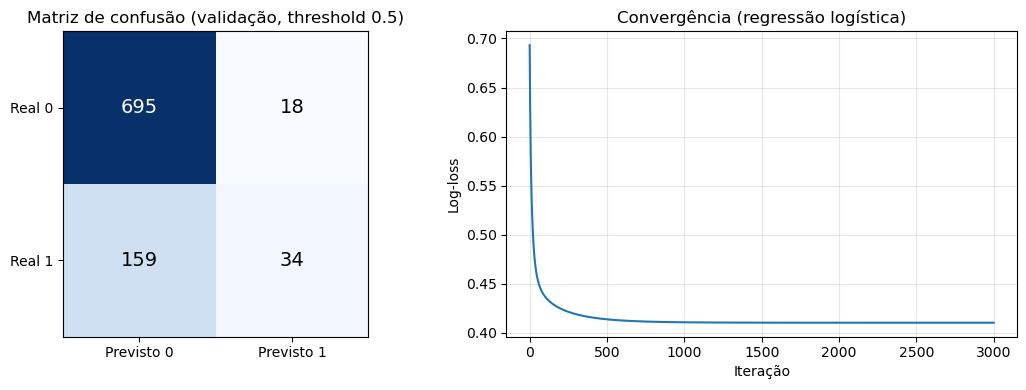

In [33]:
fig, ax = plt.subplots(1, 2, figsize=(11, 4))

mc = m_val["matriz_confusao"]
ax[0].imshow(mc, cmap="Blues")
ax[0].set_xticks([0, 1], ["Previsto 0", "Previsto 1"])
ax[0].set_yticks([0, 1], ["Real 0", "Real 1"])
ax[0].set_title("Matriz de confusão (validação, threshold 0.5)")
for i in range(2):
    for j in range(2):
        ax[0].text(j, i, mc[i, j], ha="center", va="center", fontsize=14,
                   color="white" if mc[i, j] > mc.max()/2 else "black")

ax[1].plot(hist_log)
ax[1].set_xlabel("Iteração")
ax[1].set_ylabel("Log-loss")
ax[1].set_title("Convergência (regressão logística)")
ax[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("figures/classificacao_matriz_convergencia.png", dpi=150,
            bbox_inches="tight")
plt.show()

### 3.3 Análise do threshold

A ROC-AUC é independente do threshold e mede a capacidade discriminativa do
modelo. As restantes métricas dependem do ponto de corte escolhido, pelo que
importa analisar como variam.

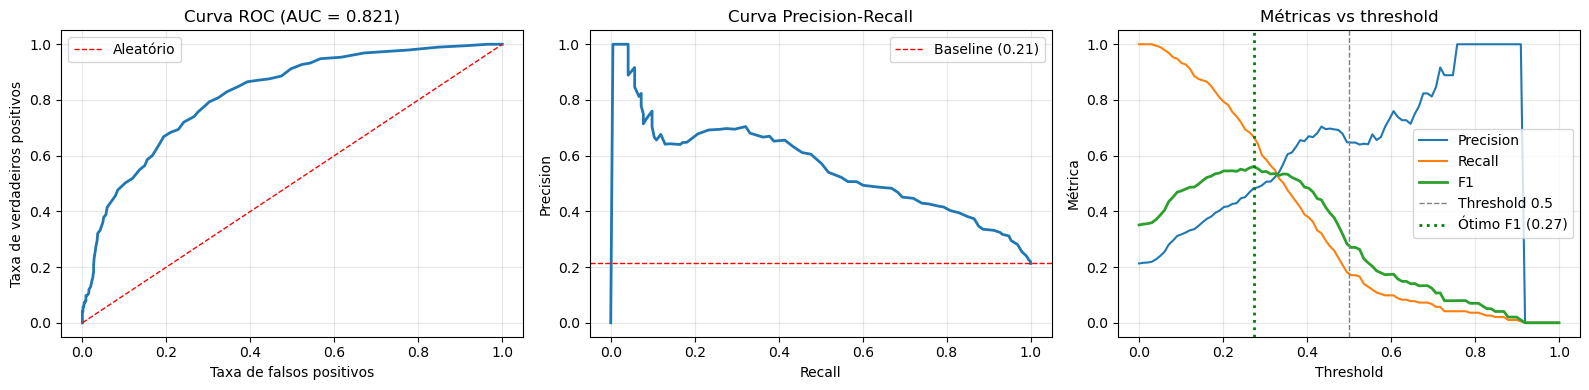

Threshold ótimo por F1 (validação): 0.273
  F1=0.5609  Precision=0.4831  Recall=0.6684


In [34]:
def curva_roc(y_real, y_prob, n_pontos=100):
    """Pontos (FPR, TPR) da curva ROC para vários thresholds."""
    ths = np.linspace(0, 1, n_pontos)
    fprs, tprs = [], []
    for t in ths:
        pred = (y_prob >= t).astype(int)
        tp = ((pred == 1) & (y_real == 1)).sum()
        fp = ((pred == 1) & (y_real == 0)).sum()
        fn = ((pred == 0) & (y_real == 1)).sum()
        tn = ((pred == 0) & (y_real == 0)).sum()
        tprs.append(tp / (tp + fn) if (tp + fn) else 0)
        fprs.append(fp / (fp + tn) if (fp + tn) else 0)
    return np.array(fprs), np.array(tprs), ths


fpr, tpr, ths = curva_roc(y_val_bin, prob_val)
precisions, recalls, f1s = [], [], []
for t in ths:
    m = metricas_log(y_val_bin, (prob_val >= t).astype(int))
    precisions.append(m["precision"]); recalls.append(m["recall"]); f1s.append(m["f1"])

fig, ax = plt.subplots(1, 3, figsize=(16, 4))

ax[0].plot(fpr, tpr, lw=2)
ax[0].plot([0, 1], [0, 1], "r--", lw=1, label="Aleatório")
ax[0].set_xlabel("Taxa de falsos positivos")
ax[0].set_ylabel("Taxa de verdadeiros positivos")
ax[0].set_title(f"Curva ROC (AUC = {m_val['roc_auc']:.3f})")
ax[0].legend(); ax[0].grid(True, alpha=0.3)

ax[1].plot(recalls, precisions, lw=2)
ax[1].axhline(y_val_bin.mean(), color="red", ls="--", lw=1,
              label=f"Baseline ({y_val_bin.mean():.2f})")
ax[1].set_xlabel("Recall"); ax[1].set_ylabel("Precision")
ax[1].set_title("Curva Precision-Recall")
ax[1].legend(); ax[1].grid(True, alpha=0.3)

ax[2].plot(ths, precisions, label="Precision")
ax[2].plot(ths, recalls, label="Recall")
ax[2].plot(ths, f1s, label="F1", lw=2)
ax[2].axvline(0.5, color="gray", ls="--", lw=1, label="Threshold 0.5")
melhor_idx = int(np.argmax(f1s))
ax[2].axvline(ths[melhor_idx], color="green", ls=":", lw=2,
              label=f"Ótimo F1 ({ths[melhor_idx]:.2f})")
ax[2].set_xlabel("Threshold"); ax[2].set_ylabel("Métrica")
ax[2].set_title("Métricas vs threshold")
ax[2].legend(); ax[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("figures/classificacao_roc_threshold.png", dpi=150, bbox_inches="tight")
plt.show()

THRESHOLD_FINAL = ths[melhor_idx]
print(f"Threshold ótimo por F1 (validação): {THRESHOLD_FINAL:.3f}")
print(f"  F1={f1s[melhor_idx]:.4f}  Precision={precisions[melhor_idx]:.4f}  "
      f"Recall={recalls[melhor_idx]:.4f}")

In [35]:
prob_teste = prever_prob(X_teste, pesos_log, bias_log)

print("=== Conjunto de TESTE ===\n")
for nome, t in [("Threshold 0.5 (padrão)", 0.5),
                (f"Threshold {THRESHOLD_FINAL:.3f} (escolhido na validação)",
                 THRESHOLD_FINAL)]:
    pred = (prob_teste >= t).astype(int)
    m = metricas_log(y_teste_bin, pred, prob_teste)
    print(nome)
    for k in ["accuracy", "precision", "recall", "f1", "roc_auc"]:
        print(f"  {k:10} {m[k]:.4f}")
    print(f"  Matriz: {m['matriz_confusao'].tolist()}\n")

=== Conjunto de TESTE ===

Threshold 0.5 (padrão)
  accuracy   0.8282
  precision  0.7632
  recall     0.1648
  f1         0.2710
  roc_auc    0.8043
  Matriz: [[723, 9], [147, 29]]

Threshold 0.273 (escolhido na validação)
  accuracy   0.7676
  precision  0.4262
  recall     0.5739
  f1         0.4891
  roc_auc    0.8043
  Matriz: [[596, 136], [75, 101]]



In [36]:
coefs_log = pd.DataFrame({"feature": X_treino.columns, "coeficiente": pesos_log})
coefs_log["odds_ratio"] = np.exp(coefs_log["coeficiente"])
coefs_log = coefs_log.reindex(
    coefs_log["coeficiente"].abs().sort_values(ascending=False).index)

print(f"Intercept: {bias_log:.4f}\n")
print("=== Top 15 coeficientes da regressão logística ===")
print(coefs_log.head(15).round(3).to_string(index=False))

coefs_log.to_csv("report/coeficientes_logistica.csv", index=False)
print(f"\nTabela completa guardada em report/coeficientes_logistica.csv")

Intercept: -1.9758

=== Top 15 coeficientes da regressão logística ===
                             feature  coeficiente  odds_ratio
              room_type_Private room        0.643       1.903
                           long_stay       -0.377       0.686
                        accommodates        0.334       1.397
                   number_of_reviews       -0.305       0.737
                         n_amenities        0.274       1.316
                     tem_smoke_alarm        0.267       1.306
neighbourhood_cleansed_Yau Tsim Mong       -0.266       0.766
                              noites       -0.248       0.780
                      minimum_nights       -0.212       0.809
                              tem_tv        0.170       1.185
     neighbourhood_cleansed_Wan Chai        0.166       1.181
      neighbourhood_cleansed_Islands       -0.160       0.852
  long_stay_x_room_type_Private room       -0.139       0.870
                            bedrooms        0.138       1.148

**Resultados da classificação:**

A proporção de positivos é 20.0% no treino (por construção), 21.3% na validação
e 19.4% no teste. O desvio é esperado e confirma que os limiares são aprendidos
apenas no treino.

**Threshold 0.5 (valor por defeito):** no teste, accuracy 0.828 mas recall de
apenas 0.165 — o modelo identifica 29 dos 176 alojamentos caros e deixa passar
147. A accuracy elevada é enganadora: classificar tudo como "não caro" daria
80.6%, quase o mesmo valor. O threshold 0.5 pressupõe classes equilibradas, o
que não se verifica numa classe positiva de 20%.

**Threshold 0.273 (otimizado por F1 na validação):** no teste, recall sobe para
0.574 e F1 de 0.271 para 0.489. A precision desce de 0.763 para 0.426, ou seja,
mais de metade dos alertas são falsos positivos. A accuracy desce para
0.768, métrica pouco informativa neste contexto.

O threshold foi selecionado **na validação** e aplicado ao teste sem novo
ajuste; a melhoria manter-se no teste confirma que não houve sobreajuste a esse
conjunto.

**Escolha do threshold na prática:** depende do custo relativo dos dois tipos
de erro. Para sinalizar alojamentos potencialmente sobrevalorizados para
revisão manual, o custo de um falso negativo (preço anómalo não detetado) é
superior ao de um falso positivo (revisão desnecessária), pelo que o threshold
mais baixo é preferível. Se cada alerta tiver custo elevado, compensa manter um
threshold alto.

**ROC-AUC de 0.804 no teste**, independente do threshold, confirma boa
capacidade discriminativa. O problema do threshold 0.5 é de calibração e não de
capacidade do modelo.

### 3.4 Interpretação dos coeficientes logísticos

Os `odds_ratio` (`exp(β)`) indicam por que fator se multiplicam as odds de o
alojamento pertencer ao top 20% do seu grupo.

| Feature | β | Odds ratio | Leitura |
|---|---|---|---|
| `room_type_Private room` | +0.643 | 1.90 | Quase duplica as odds |
| `long_stay` | −0.377 | 0.69 | Reduz as odds em 31% |
| `accommodates` | +0.334 | 1.40 | Capacidade aumenta as odds |
| `number_of_reviews` | −0.305 | 0.74 | Mais reviews, menos odds |
| `n_amenities` | +0.274 | 1.32 | Mais comodidades, mais odds |

**Aparente contradição com o modelo de regressão.** Na regressão,
`room_type_Private room` tem coeficiente **negativo** (−22.7% no preço); na
classificação tem odds ratio **1.90**. Não é inconsistência: os dois modelos
respondem a perguntas diferentes.

- A regressão prevê o **preço absoluto**, e os quartos privados são de facto
  mais baratos (mediana 292 HKD contra 987 HKD).
- A classificação prevê estar no **top 20% do próprio grupo**. Como os quartos
  privados têm preços mais concentrados, um valor moderadamente acima da média
  do grupo é suficiente para entrar no top 20%; nos alojamentos inteiros, com
  distribuição mais dispersa, é preciso um desvio maior.

Esta diferença ilustra a importância de definir a classe positiva por grupos
comparáveis: com um limiar global, a classificação limitar-se-ia a replicar a
distinção entre tipos de alojamento que a regressão já captura.

---

## Parte 4 - Conclusões

### Principais resultados

**Regressão** (log-preço, polinomiais, interações, imputação simples, L2 = 0.01):

| Conjunto | MAE | RMSE | R² |
|---|---|---|---|
| Treino | 0.3441 | 0.5014 | 0.6808 |
| Validação | 0.3560 | 0.5107 | 0.6908 |
| Teste | 0.3609 | 0.4989 | 0.6746 |

**Classificação** (top 20% por grupo, threshold 0.273):

| Métrica | Validação | Teste |
|---|---|---|
| Accuracy | — | 0.7676 |
| Precision | 0.4831 | 0.4262 |
| Recall | 0.6684 | 0.5739 |
| F1 | 0.5609 | 0.4891 |
| ROC-AUC | 0.8206 | 0.8043 |

\* threshold selecionado por maximização do F1 na validação

### Decisões com maior impacto

1. **Log-preço** — a transformação mais determinante: R² de 0.188 para 0.660.
   Também estabiliza o treino (desvio entre folds de ±0.02 contra ±1 628).
2. **Remoção de `property_type`** — eliminou multicolinearidade severa e tornou
   os coeficientes interpretáveis.
3. **Manter todas as durações com `noites` e `long_stay` como features** — o
   viés quase nulo em todos os grupos de duração confirma que a decisão
   funcionou.
4. **Threshold da classificação** — ajustar de 0.5 para 0.273 mais do que
   triplica o recall.

### Decisões com pouco impacto

1. **Tratamento de outliers** — nenhuma das três estratégias produziu diferença
   relevante. Provável razão: o log-preço já comprime os extremos.
2. **Política de imputação** — simples e agrupada são equivalentes, porque as
   variáveis imputadas são redundantes face a `accommodates`.

### Limitações

- Várias colunas previstas no enunciado estão 100% vazias nesta versão do
  ficheiro (`host_response_rate`, `host_response_time`, `host_acceptance_rate`).
- Categorias com poucas observações (Hotel room: 15, Shared room: 116) têm erro
  elevado e viés sistemático. O modelo está calibrado para as categorias
  dominantes.
- As coordenadas geográficas não são usadas diretamente; o efeito espacial é
  captado apenas ao nível do bairro.
- Os coeficientes descrevem associações, não relações causais — visível no caso
  de `number_of_reviews`.

In [37]:
from data_preparation import guardar_matriz

guardar_matriz(X_treino, [X_val, X_teste], y_treino, [y_val, y_teste])
print(f"Configuração: log-preço, polinomiais + interações, "
      f"imputação simples, sem tratamento de outliers, L2 = {L2_FINAL}")

Matrizes guardadas em data/processado/
Configuração: log-preço, polinomiais + interações, imputação simples, sem tratamento de outliers, L2 = 0.01
